# Dimer QME:  The unitary part

We already learned the quantum master equation for general cases in {numref}`ch:openqm-qme`.  Here we provide the explicit expression for a dimer. The unitary part of the Liouvillian super operator is $-i [H_{S}, \cdot]$ where $H_{S}$ is the Hamiltonian of the emitters. The system Hamiltonian consists of a free Hamiltonian for individual emitters, interaction between the emitters, and optionally external driving.  In the following, a brief summary of each terms is given.

## Free Hamiltonian and degeneracy

Each emitter is model as TLS as defined in {numref}`ssec:TLS`.  The product basis for the dimer is given by {eq}`eq:product-basis-2`.  The explicit expression of spin operators {eq}`eq:sigma-N` for $N=2$ is

$$
\sigma_{1}^{\mu} = \sigma^{\mu} \otimes I, \qquad \sigma_{2}^{\mu} = I \otimes \sigma^{\mu} , \qquad \mu = x,y,z, \pm.
$$


Using these operators, the free Hamiltonian of a dimer is given by

$$
H_{0} = \frac{\omega_{0}}{2} \left(\sigma^{z}_{1} + \sigma^{z}_{2}\right).
$$(eq:H0-dimer)

It has energy eigen values $E_{ee}=\omega_{0}$, $E_{ge}=E_{eg}=0$, and $E_{gg}=-\omega_{0}$.  The product basis, $|gg\rangle$, $|ge\rangle$, $|eg\rangle$, and $|ee\rangle$ are the corresponding eigen vectors, respectively.  


````{admonition}  **QuTiP Note**
:class: note
:name: qutip:tensor product

To construct a new operator for the dimer, we need to use tensor product and an identiy operator.

* Identity operator in 2D Hilbert space :  `qeye(2)`
* Tensor product of A and B:  `tensor(A,B)`

Example:  Define $\sigma^{z}_{1}$ and $\sigma^{z}_{2}$ and store them in a list

```
sz = [tensor(sigmaz(),qeye(2)), tensor(qeye(2),sigmaz()]
```

````

## Alternative basis set

Notice the degeneracy in the energy spectrum. The energy eigen vectors are not unique in this case. Any linear combination of $|ge\rangle$ and $∣eg\rangle$ is an energy eigen vector.  Taking this freedom, another basis set, known as the Dicke basis, is often used:

$$
|e\rangle = |ee\rangle, \quad |s\rangle = \frac{1}{\sqrt{2}}\left(|eg\rangle+|ge\rangle\right), \qquad |a\rangle = \frac{1}{\sqrt{2}}\left(|eg\rangle-|ge\rangle\right), \qquad |g\rangle = |gg\rangle.
$$(eq:sa-basis)

which can be also expressed in the angular momentum eigen vectors $|J,M\rangle$.

The triplet states are

$$
|1,1\rangle = |e\rangle, \qquad |1,0\rangle = |s\rangle, \qquad |1,-1\rangle = |g\rangle
$$(eq:triplet)

and the single state is

$$
|0,0\rangle = |a\rangle.
$$(eq:singlet)

This basis is invariant with respect to the exchange of the emitters.  In fact, $|s\rangle$ and $|a\rangle$ are symmetric, and anti-symmetric state, respectively.

Other choices of basis set are possible.  We chose a convenient one based on other parts of the Hamiltonian, and also on what a detector measures. 

## Dipole-diploe coupling

The diople-dipole coupling for $N=2$ is

$$
H_\text{dd} = \Omega_{12} \left(\sigma^{+}_{1}\sigma^{-}_{2} + \sigma^{+}_{2}\sigma^{-}_{1}\right).
$$(eq:H_dd-2)

and the coefficient is 

$$
\Omega_{12} = - \frac{3\gamma_0}{4} \left[ \left(1 - \cos^2 \theta_{12}\right) \frac{\cos(k_0 r_{12})}{k_0 r_{12}}
+ \left(1-3 \cos^2 \theta_{12} \right) \left (\frac{\sin(k_0 r_{12})}{(k_0 r_{12})^2} -  \frac{\cos(k_0 r_{12})}{(k_0 r_{12})^3} \right) \right]
$$(eq:Omega_12)

where $\theta_{12}$ is the angle betwen $\mathbf{d}$ and $\mathbf{r}_{12}$ and $\gamma^{0}$ is the rate of spontaneous emission.

The main role of this coupling is to lift the degeneracy in the free Hamiltonian. Digonalizing $H_{0}+H_{dd}$, we find the basis vectors {eq}`eq:sa-basis` are the energy eigenvectors and The corresponding energy eigenvalues are $E_{e}=\omega_{0}$, $E_{s}=\Omega_{12}$, $E_{a}=-\Omega_{12}$ and $E_{g}=-\omega_{0}$, respectively.   Optical transitions take place between these energy eigenstates.  The corresponding collapse operators must be consistent with these transitions.

There is a problem with {eq}`eq:Omega_12`. As $r_{12} \rightarrow 0$, it diverges.
(See the plot below.)  The origin of the divergence is known and there have been various attempts to mitigate the divergence. The fact that the actual shift of the energy observed by experiments is very minute ($\Omega_{12} \sim 0.01 \omega_{0}$) and thus the dipole-dipole coupling is not expected to play a significant role in most cases.  In our model, $H_{dd}$ is included just for completeness but we do not use the formula for {eq}`eq:Omega_12`. Rather we consider the coefficient as a parameter ($\Omega_{12} < \omega_{0}$).  For $r_{12}/\lambda_{0} \gg 1$, we assume $\Omega_{12}=0$.   

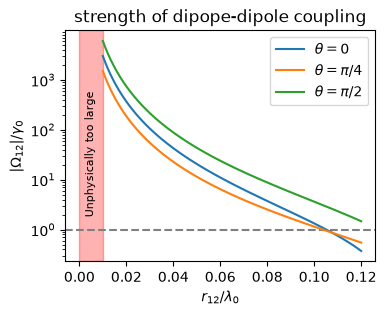

In [10]:
import numpy as np
import matplotlib.pyplot as plt

omega0=1.0
gamma0=0.1

def f(x,theta):
    y=(1-np.cos(theta)**2)*np.cos(x)/x + (1-3*np.sin(theta)**2)*(np.sin(x)/x**2 - np.cos(x)/x**3)
    return -y*3/4

x0=np.linspace(0.01,0.12,100)
x1=2*np.pi*x0
y1 = f(x1,0)
y2 = f(x1,np.pi/4)
y3 = f(x1,np.pi/2)
plt.figure(figsize=(4,3))
plt.title("strength of dipope-dipole coupling")
plt.axhline(y=1,color='grey',ls='--')
plt.semilogy(x0,abs(y1),label=r"$\theta=0$")
plt.semilogy(x0,abs(y2),label=r"$\theta=\pi/4$")
plt.semilogy(x0,abs(y3),label=r"$\theta=\pi/2$")
plt.xlabel(r"$r_{12}/\lambda_{0}$")
plt.ylabel(r"$|\Omega_{12}|/\gamma_{0}$")
plt.legend(loc=1)
plt.axvspan(0, 0.01, color='red', alpha=0.3)
plt.text(0.002,2,"Unphysically too large",size=8,rotation="vertical")
plt.show()

## External driving

In many experiments, the emitters are driven by an additional radiation, which is usually a laser. 
As introduced in {numref}`sec:driving`, the laser is assumed to be a classical radiation and the rotating wave approximation (RWA) is used to eliminate the time-dependency.  For a dimer, the system Hamiltonian under RWA is

$$
H^\text{RWA}_{S} = \frac{\Delta}{2} \left(\sigma^{z}_{1} + \sigma^{z}_{2}\right)- \Omega_{12} \left(\sigma^{+}_{1}\sigma^{-}_{2} + \sigma^{+}_{2}\sigma^{-}_{1}\right) - \frac{\Omega_{L}}{2} \left (e^{i \phi_{1}} \sigma^{+}_{1} + e^{-i \phi_{1}} \sigma^{-}_{1}\right) - \frac{\Omega_{L}}{2} \left (e^{i \phi_{2}} \sigma^{+}_{2} + e^{-i \phi_{2}} \sigma^{-}_{2}\right) 
$$(eq:H-RWA-2)

where $\phi_{j} = \mathbf{k}_{L}\cdot \mathbf{x}_{j}$.

